Install libraries

In [7]:
!pip install -q imbalanced-learn

Import libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

Load the dataset

In [9]:
df = pd.read_csv("/content/creditcard.csv")

Display first 5 rows

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Check dataset size

In [11]:
df.shape

(75357, 31)

Check column names

In [12]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

The important target column is:

Class

Check information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75357 entries, 0 to 75356
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    75357 non-null  int64  
 1   V1      75357 non-null  float64
 2   V2      75357 non-null  float64
 3   V3      75357 non-null  float64
 4   V4      75357 non-null  float64
 5   V5      75357 non-null  float64
 6   V6      75357 non-null  float64
 7   V7      75357 non-null  float64
 8   V8      75357 non-null  float64
 9   V9      75357 non-null  float64
 10  V10     75357 non-null  float64
 11  V11     75357 non-null  float64
 12  V12     75357 non-null  float64
 13  V13     75357 non-null  float64
 14  V14     75357 non-null  float64
 15  V15     75357 non-null  float64
 16  V16     75357 non-null  float64
 17  V17     75357 non-null  float64
 18  V18     75357 non-null  float64
 19  V19     75357 non-null  float64
 20  V20     75357 non-null  float64
 21  V21     75357 non-null  float64
 22

Check missing values

In [14]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Check statistics

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,...,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75357.000000,75356.000000,75356.000000,75356.000000,75356.000000
mean,36110.239845,-0.252779,-0.028574,0.678975,0.166227,-0.274493,0.097547,-0.114049,0.054618,0.003693,...,-0.029030,-0.105362,-0.038348,0.007033,0.135245,0.024984,0.002408,0.003170,97.386784,0.002428
std,14826.849221,1.877372,1.660941,1.402475,1.370891,1.387110,1.305219,1.253220,1.233482,1.151622,...,0.735801,0.636560,0.620647,0.596267,0.439933,0.498227,0.388885,0.325915,271.107132,0.049220
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,29808.000000,-1.014563,-0.595725,0.190522,-0.725740,-0.891744,-0.640664,-0.604835,-0.141745,-0.678360,...,-0.225114,-0.524347,-0.178518,-0.324097,-0.128460,-0.327494,-0.063013,-0.005684,7.680000,0.000000
50%,39061.000000,-0.246462,0.070645,0.766814,0.185626,-0.306681,-0.153060,-0.073692,0.067915,-0.080156,...,-0.059348,-0.079669,-0.050641,0.063602,0.173419,-0.073581,0.009421,0.022871,26.690000,0.000000
75%,47465.000000,1.153590,0.724071,1.398870,1.049550,0.263561,0.491405,0.418052,0.346752,0.644633,...,0.116887,0.309364,0.080096,0.404425,0.422121,0.305705,0.082473,0.075966,88.982500,0.000000
max,56021.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,17.297845,4.014444,5.525093,3.517346,12.152401,33.847808,19656.530000,1.000000


Check fraud distribution

In [16]:
df["Class"].value_counts()

,count
Class,
0.0,75173
1.0,183


0 = Normal transaction
1 = Fraudulent transaction

Visualize class imbalance

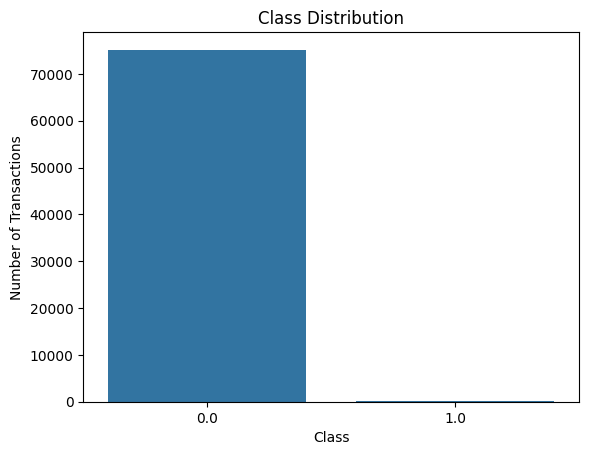

In [17]:
sns.countplot(x=df["Class"])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

Separate X and y

X contains the input features.

y contains the fraud label.

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [19]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (75357, 30)
y shape: (75357,)


Split the dataset

Important: We split the dataset before SMOTE.

In [20]:
not_nan_mask = y.notna()
X = X[not_nan_mask]
y = y[not_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60284, 30)
Testing data: (15072, 30)


Apply SMOTE

In [22]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [23]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    60138
1.0      146
Name: count, dtype: int64

After SMOTE:
Class
0.0    60138
1.0    60138
Name: count, dtype: int64


Scale the data

For Logistic Regression:

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

Create Logistic Regression model

In [25]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Train Logistic Regression

In [26]:
logistic_model.fit(
    X_train_scaled,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

Make Logistic Regression predictions

In [27]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [28]:
y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

Evaluate Logistic Regression

In [29]:
precision_lr = precision_score(
    y_test,
    y_pred_lr
)

recall_lr = recall_score(
    y_test,
    y_pred_lr
)

roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression")
print("-------------------")
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("ROC-AUC:", roc_auc_lr)

Logistic Regression
-------------------
Precision: 0.17326732673267325
Recall: 0.9459459459459459
ROC-AUC: 0.9932230201601668


Classification report

In [30]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     15035
         1.0       0.17      0.95      0.29        37

    accuracy                           0.99     15072
   macro avg       0.59      0.97      0.64     15072
weighted avg       1.00      0.99      0.99     15072



Create Random Forest model

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

Train Random Forest

In [32]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_jobs=-1, random_state=42)

Make predictions

In [33]:
y_pred_rf = rf_model.predict(X_test)

Get probabilities:

In [34]:
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

Evaluate Random Forest

In [35]:
precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("-------------")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest
-------------
Precision: 0.8717948717948718
Recall: 0.918918918918919
ROC-AUC: 0.9973988621145257


Classification report

In [36]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15035
         1.0       0.87      0.92      0.89        37

    accuracy                           1.00     15072
   macro avg       0.94      0.96      0.95     15072
weighted avg       1.00      1.00      1.00     15072



Compare both models

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.173267,0.945946,0.993223
1,Random Forest,0.871795,0.918919,0.997399


Random Forest Confusion Matrix

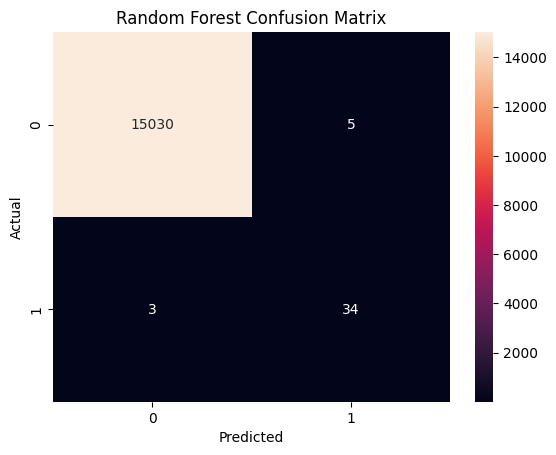

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC Curve for Logistic Regression

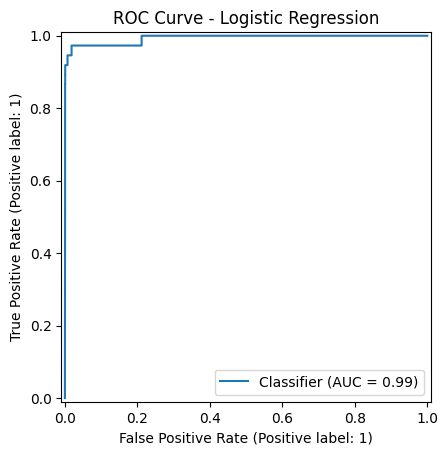

In [39]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

ROC Curve for Random Forest

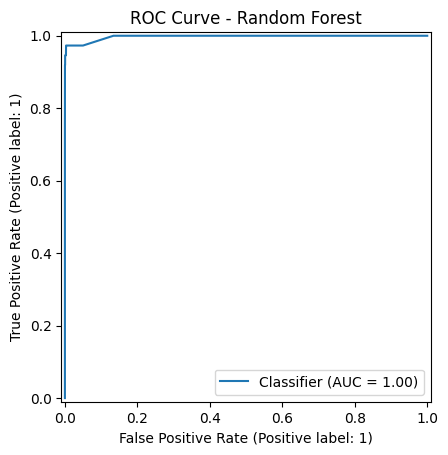

In [40]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Random Forest")

plt.show()

Hyperparameter tuning

In [48]:
param_grid = {
    "n_estimators": [50],
    "max_depth": [10]
}

Faster GridSearchCV

In [49]:
grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1
)

Run the tuning

In [50]:
grid_search.fit(
    X_train_smote,
    y_train_smote
)

GridSearchCV(cv=2, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1, param_grid={'max_depth': [10], 'n_estimators': [50]},
             scoring='roc_auc')

Best parameters

In [51]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 50}


Best ROC-AUC

In [52]:
print("Best ROC-AUC:")
print(grid_search.best_score_)

Best ROC-AUC:
0.9999670898939158


Get the tuned model

In [53]:
best_rf = grid_search.best_estimator_

Final predictions

In [54]:
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(
    X_test
)[:, 1]

Final evaluation

In [55]:
final_precision = precision_score(
    y_test,
    y_pred_best
)

final_recall = recall_score(
    y_test,
    y_pred_best
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob_best
)

print("Tuned Random Forest")
print("-------------------")
print("Precision:", final_precision)
print("Recall:", final_recall)
print("ROC-AUC:", final_roc_auc)

Tuned Random Forest
-------------------
Precision: 0.6938775510204082
Recall: 0.918918918918919
ROC-AUC: 0.9991748982104819


Final model comparison

In [56]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        final_precision
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        final_recall
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        final_roc_auc
    ]
})

final_results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.173267,0.945946,0.993223
1,Random Forest,0.871795,0.918919,0.997399
2,Tuned Random Forest,0.693878,0.918919,0.999175
